In [70]:
import numpy as np
import matplotlib.pyplot as plt

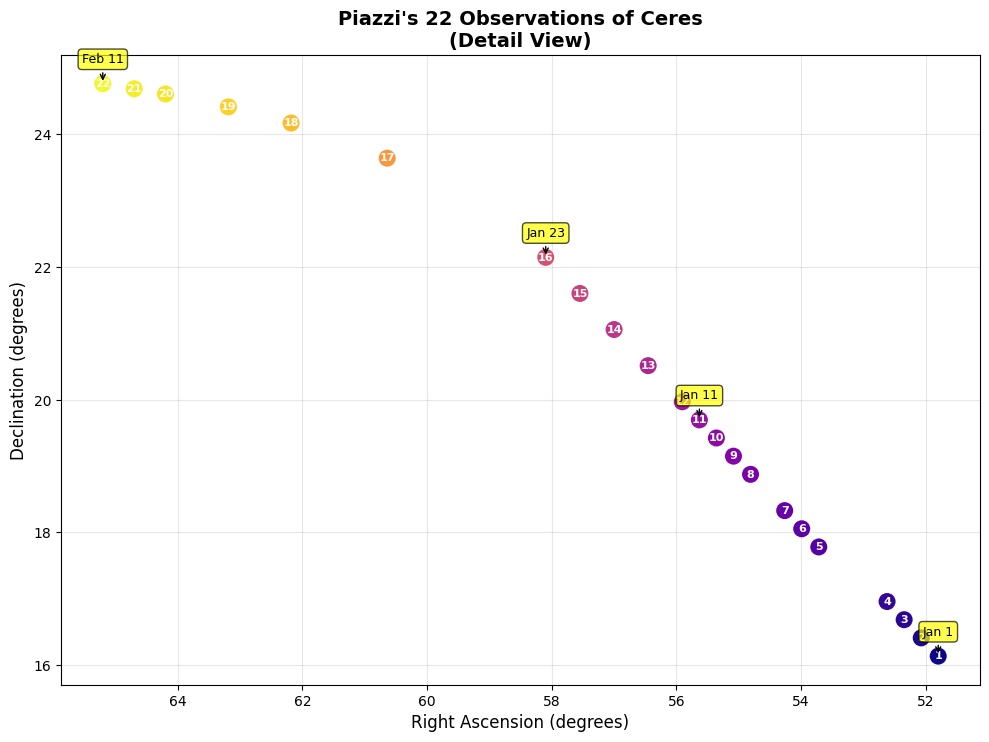

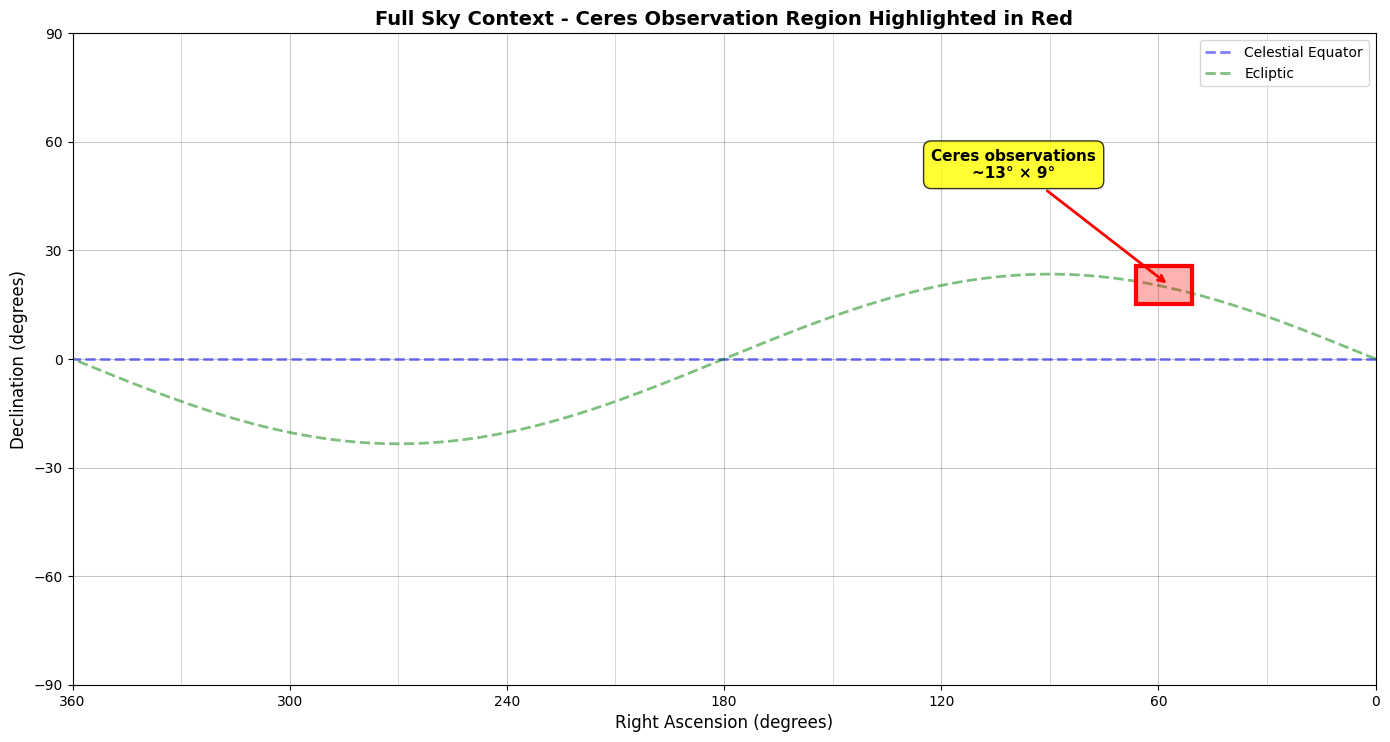


Angular span of observations:
  RA: 13.41° (804.4 arcminutes)
  Dec: 8.63° (518.0 arcminutes)
  Total sky area: 115.74 square degrees
  Percentage of sky: 0.2806%

This is roughly equivalent to:
  463 full moons (each ~0.25 sq deg)


In [82]:
# Piazzi's observations
t_days = np.array([0, 1, 2, 3, 6, 7, 8, 10, 11, 12, 13, 14, 16, 18, 20, 22, 
                   31, 35, 37, 39, 40, 41])

RA_deg = np.array([51.797, 52.070, 52.344, 52.618, 53.714, 53.988, 54.261,
                   54.809, 55.083, 55.357, 55.630, 55.904, 56.452, 56.999,
                   57.547, 58.096, 60.640, 62.182, 63.189, 64.197, 64.700, 65.204])

Dec_deg = np.array([16.133, 16.408, 16.682, 16.956, 17.779, 18.053, 18.327,
                    18.874, 19.148, 19.422, 19.695, 19.968, 20.513, 21.058,
                    21.602, 22.146, 23.642, 24.172, 24.416, 24.610, 24.688, 24.766])

# ============ FIGURE 1: Detail View ============
fig, ax = plt.subplots(figsize=(10, 8))

# Plot trajectory
ax.scatter(RA_deg, Dec_deg, c=t_days, cmap='plasma', 
       s=150, edgecolors='black', linewidth=0, zorder=3)

# Add observation numbers
for i, (ra, dec, day) in enumerate(zip(RA_deg, Dec_deg, t_days)):
    ax.annotate(f'{i+1}', (ra, dec), 
          fontsize=8, ha='center', va='center', 
          color='white', fontweight='bold')

# Add date labels for key observations
key_dates = [(0, 'Jan 1'), (10, 'Jan 11'), (15, 'Jan 23'), (21, 'Feb 11')]
for idx, date_str in key_dates:
    ax.annotate(date_str, (RA_deg[idx], Dec_deg[idx]),
          xytext=(0, 15), textcoords='offset points',
          fontsize=9, ha='center',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
          arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax.invert_xaxis()
ax.set_xlabel('Right Ascension (degrees)', fontsize=12)
ax.set_ylabel('Declination (degrees)', fontsize=12)
ax.set_title('Piazzi\'s 22 Observations of Ceres\n(Detail View)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_aspect(1.0 / np.cos(np.radians(20)))

plt.tight_layout()
plt.show()

# ============ FIGURE 2: Full Sky Context ============
fig, ax = plt.subplots(figsize=(14, 8))

# Plot full sky grid
ra_grid = np.linspace(0, 360, 360)
for dec in range(-90, 91, 30):
    ax.plot(ra_grid, [dec]*len(ra_grid), 'k-', alpha=0.2, linewidth=0.5)

dec_grid = np.linspace(-90, 90, 180)
for ra in range(0, 360, 30):
    ax.plot([ra]*len(dec_grid), dec_grid, 'k-', alpha=0.2, linewidth=0.5)

# Highlight the observation region
ra_center = np.mean(RA_deg)
dec_center = np.mean(Dec_deg)
ra_range = RA_deg.max() - RA_deg.min()
dec_range = Dec_deg.max() - Dec_deg.min()

# Create a rectangle for the observation region
from matplotlib.patches import Rectangle
rect = Rectangle((RA_deg.min() - 1, Dec_deg.min() - 1), 
                 ra_range + 2, dec_range + 2,
                 linewidth=3, edgecolor='red', facecolor='red', alpha=0.3, zorder=5)
ax.add_patch(rect)

# Add a zoomed inset box
rect_border = Rectangle((RA_deg.min() - 1, Dec_deg.min() - 1), 
                        ra_range + 2, dec_range + 2,
                        linewidth=3, edgecolor='red', facecolor='none', zorder=6)
ax.add_patch(rect_border)

# Add annotation for the tiny region
ax.annotate('Ceres observations\n~13° × 9°', 
            xy=(ra_center, dec_center),
            xytext=(100, 50), fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            ha='center', fontweight='bold')

# Add celestial equator
ax.plot([0, 360], [0, 0], 'b--', linewidth=2, alpha=0.5, label='Celestial Equator')

# Add ecliptic (approximate)
ecliptic_ra = np.linspace(0, 360, 1000)
ecliptic_dec = 23.44 * np.sin(np.radians(ecliptic_ra))
ax.plot(ecliptic_ra, ecliptic_dec, 'g--', linewidth=2, alpha=0.5, label='Ecliptic')

ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)
ax.invert_xaxis()
ax.set_xlabel('Right Ascension (degrees)', fontsize=12)
ax.set_ylabel('Declination (degrees)', fontsize=12)
ax.set_title('Full Sky Context - Ceres Observation Region Highlighted in Red', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Add RA labels
ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
ax.set_yticks([-90, -60, -30, 0, 30, 60, 90])

plt.tight_layout()
plt.show()

# ============ STATISTICS ============
print(f"\nAngular span of observations:")
print(f"  RA: {ra_range:.2f}° ({ra_range*60:.1f} arcminutes)")
print(f"  Dec: {dec_range:.2f}° ({dec_range*60:.1f} arcminutes)")
print(f"  Total sky area: {ra_range * dec_range:.2f} square degrees")
print(f"  Percentage of sky: {100 * ra_range * dec_range / 41253:.4f}%")
print(f"\nThis is roughly equivalent to:")
print(f"  {ra_range * dec_range / 0.25:.0f} full moons (each ~0.25 sq deg)")

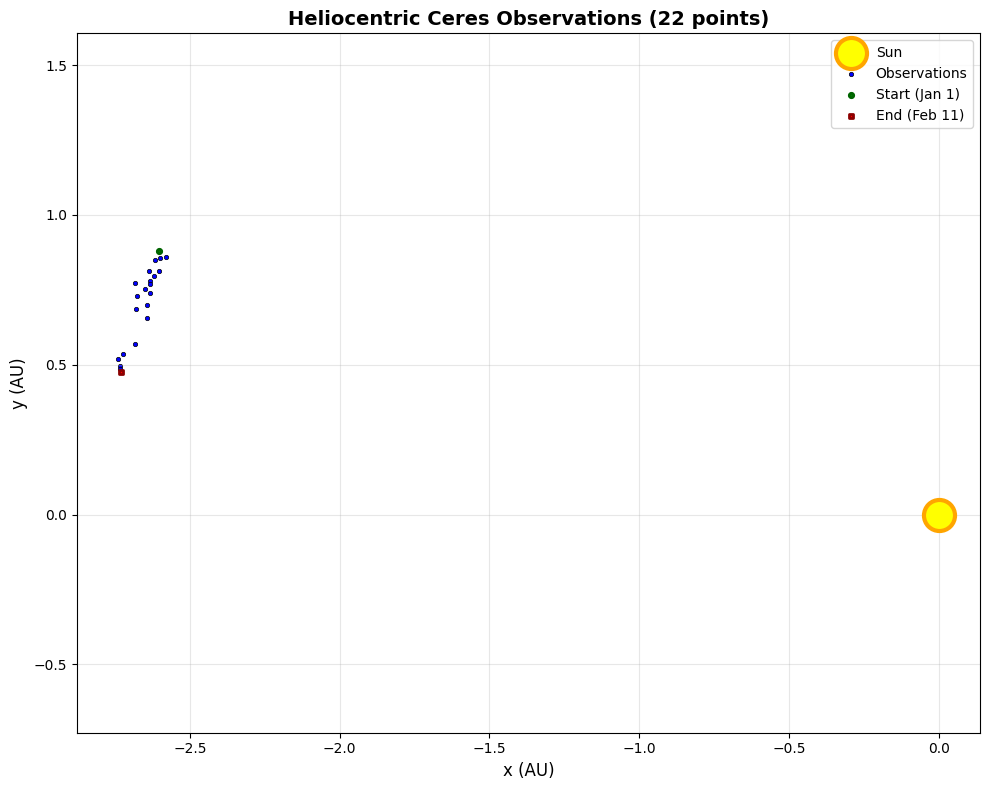

In [72]:
# ============================================================================
# GENERATE NOISY HELIOCENTRIC CERES DATA (22 observations)
# ============================================================================

np.random.seed(42)  # For reproducibility

# Same observation times as Piazzi
t_days = np.array([0, 1, 2, 3, 6, 7, 8, 10, 11, 12, 13, 14, 16, 18, 20, 22, 
                   31, 35, 37, 39, 40, 41])

# True orbital parameters
a_true = 2.7670
e_true = 0.0758
omega_true = np.radians(73.0)

# Calculate true heliocentric positions
period_days = 4.60 * 365.25
degrees_per_day = 360.0 / period_days
helio_longitude_true = 161.35 + t_days * degrees_per_day
theta_true = np.radians(helio_longitude_true)

p_true = a_true * (1 - e_true**2)
r_true = p_true / (1 + e_true * np.cos(theta_true - omega_true))

# Add realistic noise
angular_error_std = 0.007  # degrees
distance_error_std = 0.020  # AU

helio_longitude = helio_longitude_true + np.random.normal(0, angular_error_std, len(t_days))
helio_distance = r_true + np.random.normal(0, distance_error_std, len(t_days))
theta = np.radians(helio_longitude)

# ============================================================================
# PLOT - SIMPLE WITH SUN
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Convert to Cartesian coordinates
x = helio_distance * np.cos(theta)
y = helio_distance * np.sin(theta)

# Plot Sun at origin
ax.scatter([0], [0], s=500, c='yellow', marker='o', 
           edgecolors='orange', linewidth=3, label='Sun', zorder=5)

# Plot observations
ax.scatter(x, y, s=10, c='blue', 
           edgecolors='black', linewidth=0.5, label='Observations')

# Mark first and last
ax.scatter(x[0], y[0], s=10, c='green', 
           edgecolors='darkgreen', linewidth=2, marker='o', label='Start (Jan 1)', zorder=4)
ax.scatter(x[-1], y[-1], s=10, c='red', 
           edgecolors='darkred', linewidth=2, marker='s', label='End (Feb 11)', zorder=4)

ax.set_xlabel('x (AU)', fontsize=12)
ax.set_ylabel('y (AU)', fontsize=12)
ax.set_title('Heliocentric Ceres Observations (22 points)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.tight_layout()
plt.show()

In [73]:
# US population data (in millions) from 1790 to 2020
us_population = [3.929, 5.308, 7.240, 9.638, 12.87, 17.07, 23.19, 31.44, 39.82, 50.19, 62.95, 76.21,
92.22, 106.0, 122.8, 132.2, 150.7, 179.3, 203.3, 226.5, 248.7, 281.4, 308.7, 331.4]

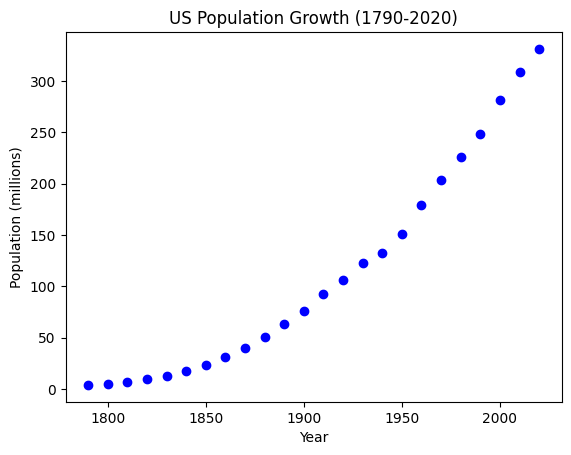

In [74]:
plt.scatter(range(1790, 2021, 10), us_population, color='blue', label='Population Data')
plt.xlabel('Year')
plt.ylabel('Population (millions)')
plt.title('US Population Growth (1790-2020)')
plt.show()

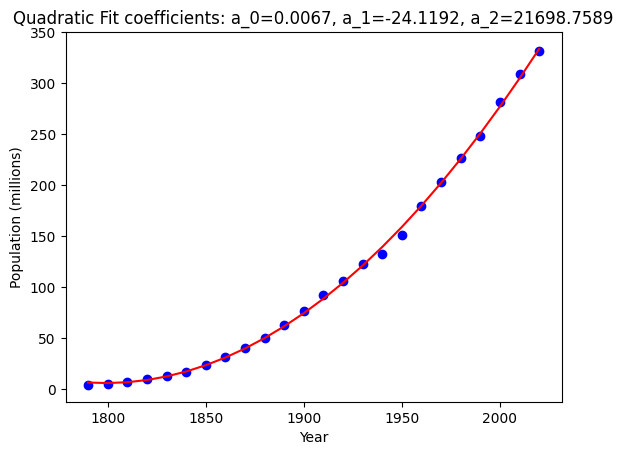

In [75]:
# quadratic fit for US population data
years = np.array(range(1790, 2021, 10))
coefficients = np.polyfit(years, us_population, 2)

# plot the quadratic fit and the original data
plt.scatter(years, us_population, color='blue', label='Population Data')

# Generate fitted values
fitted_population = np.polyval(coefficients, years)

# Plot fitted curve and fitted points
plt.plot(years, fitted_population, color='red', label='Quadratic Fit')

plt.xlabel('Year')
plt.ylabel('Population (millions)')
plt.title('Quadratic Fit coefficients: a_0={:.4f}, a_1={:.4f}, a_2={:.4f}'.format(*coefficients))
plt.show()

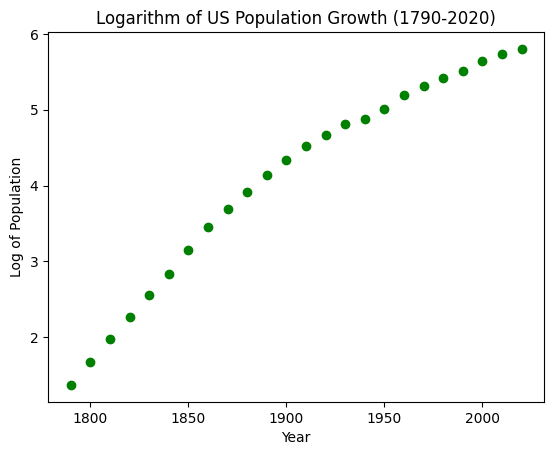

In [76]:
# logarithm of us_population
log_population = np.log(us_population)

#plot log population
plt.scatter(range(1790, 2021, 10), log_population, color='green', label='Log Population Data')
plt.xlabel('Year')
plt.ylabel('Log of Population')
plt.title('Logarithm of US Population Growth (1790-2020)')
plt.show()

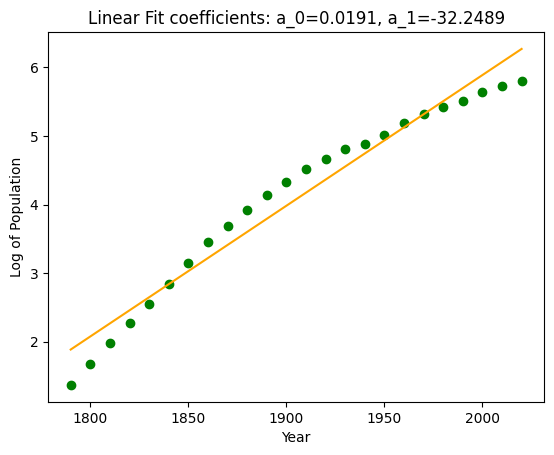

In [77]:
# linear fit for log of US population data
coefficients_log = np.polyfit(years, log_population, 1)

# plot the linear fit and the original log data
plt.scatter(years, log_population, color='green', label='Log Population Data')

# Generate fitted values for log population
fitted_log_population = np.polyval(coefficients_log, years)

# Plot fitted line and fitted points
plt.plot(years, fitted_log_population, color='orange', label='Linear Fit')
plt.xlabel('Year')
plt.ylabel('Log of Population')
plt.title('Linear Fit coefficients: a_0={:.4f}, a_1={:.4f}'.format(*coefficients_log))
plt.show()

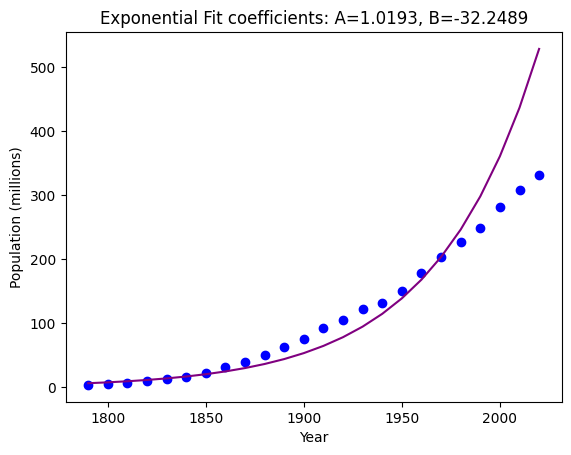

In [78]:
# translate linear fit back to original scale
original_scale_population = np.exp(coefficients_log[0] * years + coefficients_log[1])

# plot the original data and the exponential fit
plt.scatter(years, us_population, color='blue', label='Population Data')
# Plot fitted curve and fitted points
plt.plot(years, original_scale_population, color='purple', label='Exponential Fit')
plt.xlabel('Year')
plt.ylabel('Population (millions)')
plt.title('Exponential Fit coefficients: A={:.4f}, B={:.4f}'.format(np.exp(coefficients_log[0]), coefficients_log[1]))
plt.show()

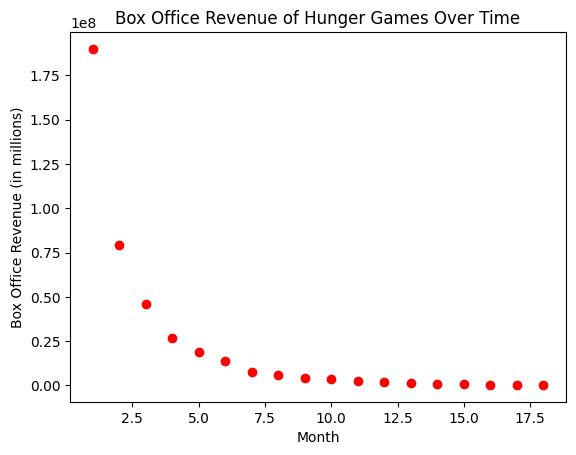

In [79]:
# Hunger Games data (in millions) in months

box_office = [189932838, 79406327, 46230374, 26830921, 18804290, 13822248, 7474688, 6129424, 4377675, 3764963, 2426574, 1713298, 1426102, 1031985, 694947, 518242, 460578, 317909]

# plot box office data
months = np.arange(1, len(box_office) + 1)
plt.scatter(months, box_office, color='red', label='Box Office Data')
plt.xlabel('Month')
plt.ylabel('Box Office Revenue (in millions)')
plt.title('Box Office Revenue of Hunger Games Over Time')
plt.show()

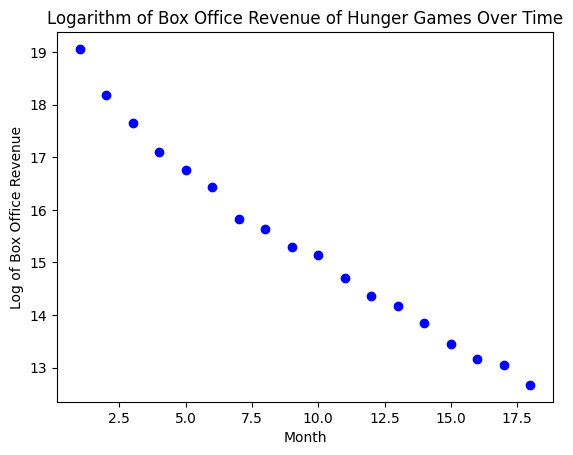

In [80]:
# log of box office data
log_box_office = np.log(box_office)

# plot log box office data
plt.scatter(months, log_box_office, color='blue', label='Log Box Office Data')
plt.xlabel('Month')
plt.ylabel('Log of Box Office Revenue')
plt.title('Logarithm of Box Office Revenue of Hunger Games Over Time')
plt.show()